<a href="https://colab.research.google.com/github/nagasuneetha1507/Github_Assistence/blob/main/Emotion_Detection_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Emotion Detection Project")
print("Using Deep Learning - LSTM")


Emotion Detection Project
Using Deep Learning - LSTM


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!wget -O emotion_dataset.zip https://github.com/dair-ai/emotion_dataset/raw/master/data/train.csv

!ls -lh emotion_dataset.zip

--2026-09-06 08:19:52--  https://github.com/dair-ai/emotion_dataset/raw/master/data/train.csv
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-06 08:19:52 ERROR 404: Not Found.

-rw-r--r-- 1 root root 0 Sep  6 08:19 emotion_dataset.zip


In [ ]:
!pip install -q datasets

from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

print(dataset)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)
print("Testing data:", test_df.shape)
train_df.head()

Training data: (16000, 2)
Validation data: (2000, 2)
Testing data: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
print("Columns:")
print(train_df.columns)
train_df.info()
print("Missing values:")
print(train_df.isnull().sum())
print("Duplicate rows:", train_df.duplicated().sum())
print("Emotion label counts:")
print(train_df['label'].value_counts().sort_index())
train_df.head(10)
emotion_names = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

print(emotion_names)
for i in range(10):
    label = train_df.iloc[i]['label']
    text = train_df.iloc[i]['text']
    print(f"Emotion: {emotion_names[label]}")
    print(f"Text: {text}")
    print("-" * 60)

Columns:
Index(['text', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB
Missing values:
text     0
label    0
dtype: int64
Duplicate rows: 1
Emotion label counts:
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64
{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Emotion: sadness
Text: i didnt feel humiliated
------------------------------------------------------------
Emotion: sadness
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
------------------------------------------------------------
Emotion: anger
Text: im grabbing a minute to post i feel greedy wrong
------------------

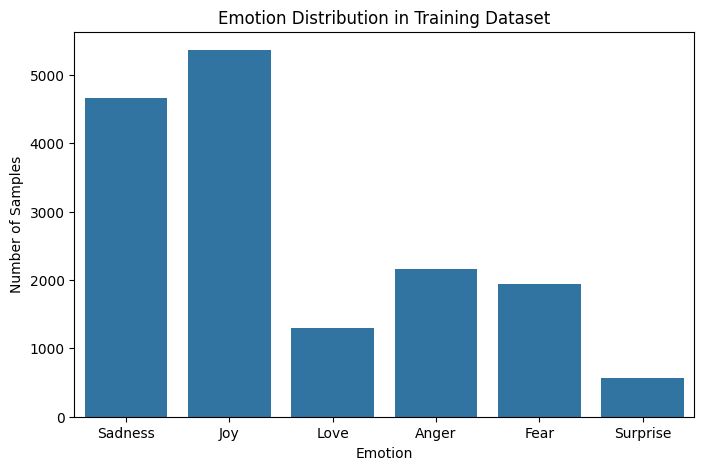

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='label',
    data=train_df
)

plt.xticks(
    ticks=range(6),
    labels=[
        'Sadness',
        'Joy',
        'Love',
        'Anger',
        'Fear',
        'Surprise'
    ]
)

plt.title('Emotion Distribution in Training Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.show()

Text length statistics:
count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64


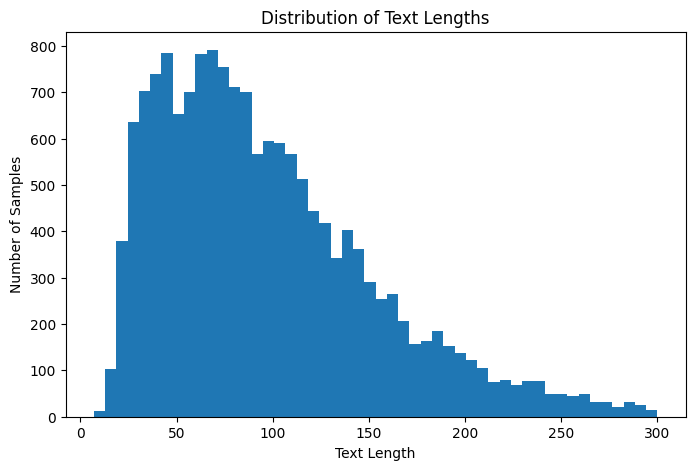

In [ ]:
train_df['text_length'] = train_df['text'].apply(len)

print("Text length statistics:")
print(train_df['text_length'].describe())
plt.figure(figsize=(8, 5))

plt.hist(train_df['text_length'], bins=50)

plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Number of Samples')

plt.show()

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)

train_df[['text', 'clean_text']].head(10)

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [ ]:
X = train_df['clean_text']
y = train_df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 texts:")
print(X.head())

print("\nFirst 5 labels:")
print(y.head())

X shape: (16000,)
y shape: (16000,)

First 5 texts:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: clean_text, dtype: object

First 5 labels:
0    0
1    0
2    3
3    2
4    3
Name: label, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12800
Testing samples: 3200


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("First training text:")
print(X_train.iloc[0])

print("\nConverted sequence:")
print(X_train_sequences[0])

First training text:
im feeling abit grouchy with kim

Converted sequence:
[17, 8, 3058, 1017, 25, 4563]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 100

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train_padded shape:", X_train_padded.shape)
print("X_test_padded shape:", X_test_padded.shape)

print("\nFirst padded sequence:")
print(X_train_padded[0])

X_train_padded shape: (12800, 100)
X_test_padded shape: (3200, 100)

First padded sequence:
[  17    8 3058 1017   25 4563    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = min(10000, len(tokenizer.word_index) + 1)

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.3275 - loss: 1.6003 - val_accuracy: 0.3297 - val_loss: 1.5724
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.3283 - loss: 1.5860 - val_accuracy: 0.3297 - val_loss: 1.5675
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.3290 - loss: 1.5851 - val_accuracy: 0.3297 - val_loss: 1.5676
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.3324 - loss: 1.5838 - val_accuracy: 0.3297 - val_loss: 1.5644
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.3333 - loss: 1.5836 - val_accuracy: 0.3297 - val_loss: 1.5648


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3350 - loss: 1.5757
Test Loss: 1.5756922960281372
Test Accuracy: 33.50%


In [ ]:
y_pred_prob = model.predict(X_test_padded)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully!")
print("First 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.values[:10])

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Predictions generated successfully!
First 10 predicted labels:
[1 1 1 1 1 1 1 1 1 1]

First 10 actual labels:
[4 2 4 0 1 0 0 3 4 1]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Sadness',
        'Joy',
        'Love',
        'Anger',
        'Fear',
        'Surprise'
    ]
))

              precision    recall  f1-score   support

     Sadness       0.00      0.00      0.00       933
         Joy       0.34      1.00      0.50      1072
        Love       0.00      0.00      0.00       261
       Anger       0.00      0.00      0.00       432
        Fear       0.00      0.00      0.00       387
    Surprise       0.00      0.00      0.00       115

    accuracy                           0.34      3200
   macro avg       0.06      0.17      0.08      3200
weighted avg       0.11      0.34      0.17      3200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


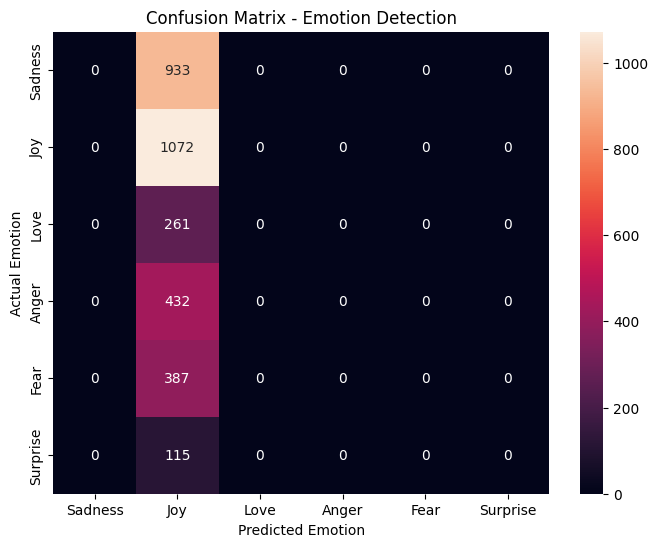

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Sadness',
        'Joy',
        'Love',
        'Anger',
        'Fear',
        'Surprise'
    ],
    yticklabels=[
        'Sadness',
        'Joy',
        'Love',
        'Anger',
        'Fear',
        'Surprise'
    ]
)

plt.title('Confusion Matrix - Emotion Detection')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.show()

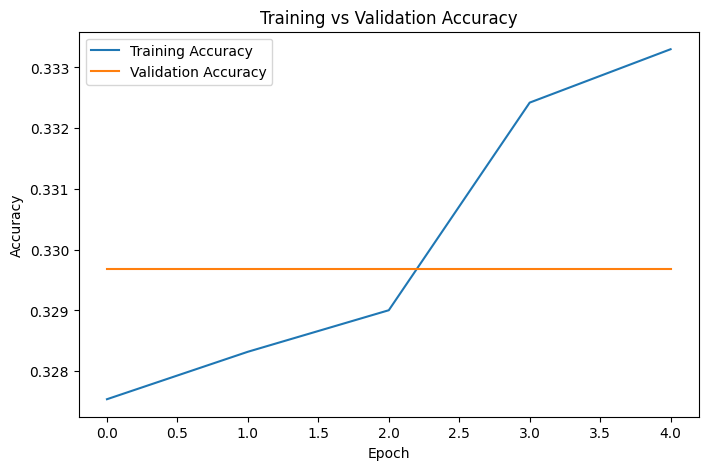

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


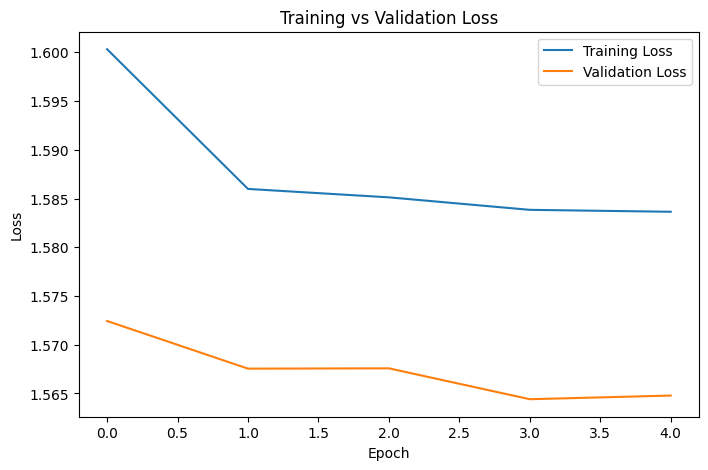

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
def predict_emotion(text):
    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    probabilities = model.predict(padded, verbose=0)[0]

    predicted_label = np.argmax(probabilities)
    predicted_emotion = emotion_names[predicted_label]
    confidence = probabilities[predicted_label] * 100

    print("Text:", text)
    print("Predicted Emotion:", predicted_emotion.upper())
    print("Confidence: {:.2f}%".format(confidence))


predict_emotion("I am so happy today!")

Text: I am so happy today!
Predicted Emotion: JOY
Confidence: 33.23%


In [ ]:
test_sentences = [
    "I am extremely happy today!",
    "I feel so lonely and sad.",
    "I love you so much.",
    "I am really angry about this.",
    "I am scared of what will happen.",
    "Wow! I can't believe this happened!"
]

for sentence in test_sentences:
    predict_emotion(sentence)
    print("-" * 60)

Text: I am extremely happy today!
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------
Text: I feel so lonely and sad.
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------
Text: I love you so much.
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------
Text: I am really angry about this.
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------
Text: I am scared of what will happen.
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------
Text: Wow! I can't believe this happened!
Predicted Emotion: JOY
Confidence: 33.23%
------------------------------------------------------------


In [ ]:
model.save("emotion_detection_lstm_model.keras")

print("Model saved successfully!")
import pickle

with open("emotion_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Model saved successfully!
Tokenizer saved successfully!


In [ ]:
import os

print("Saved files:")

for file in os.listdir():
    if file.endswith(".keras") or file.endswith(".pkl"):
        print("✅", file)

Saved files:
✅ emotion_tokenizer.pkl
✅ emotion_detection_lstm_model.keras


# 😊 Emotion Detection from Text Using Deep Learning and LSTM

## Project Objective

This project uses a Deep Learning model based on Long Short-Term Memory (LSTM)
to classify text into six different emotions:

- Sadness
- Joy
- Love
- Anger
- Fear
- Surprise

## Project Workflow

1. Dataset Collection
2. Data Exploration
3. Data Visualization
4. Text Preprocessing
5. Tokenization
6. Sequence Padding
7. LSTM Model Building
8. Model Training
9. Model Evaluation
10. Confusion Matrix
11. Custom Text Prediction
12. Model Saving